In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
BASE_DIR = Path(".")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(
    PROCESSED_DIR / "forecasting_dataset.csv"
)

df["date"] = pd.to_datetime(df["date"])

In [ ]:
print(df.shape)
df.head()

(720, 29)


,date,estate_id,estate_name,region,month,quarter,month_sin,month_cos,area_ha,plant_age_years,...,tbs_lag_1,tbs_lag_3,tbs_lag_6,tbs_lag_12,tbs_rolling_mean_3,tbs_rolling_mean_6,tbs_rolling_mean_12,tbs_growth_1m,tbs_growth_12m,tbs_production_ton
0,2020-01-01,EST001,Estate Lampung 01,Sumatra,1,1,0.500000,8.660254e-01,4250,10,...,8680.5,7933.2,9134.3,8132.4,8177.300000,8281.833333,8307.600000,-0.041749,0.022835,8318.1
1,2020-02-01,EST001,Estate Lampung 01,Sumatra,2,1,0.866025,5.000000e-01,4250,10,...,8318.1,7918.2,7770.7,8492.3,8305.600000,8145.800000,8323.075000,0.016350,-0.004498,8454.1
2,2020-03-01,EST001,Estate Lampung 01,Sumatra,3,1,1.000000,6.123234e-17,4250,10,...,8454.1,8680.5,8254.1,8186.5,8484.233333,8259.700000,8319.891667,0.151690,0.189336,9736.5
3,2020-04-01,EST001,Estate Lampung 01,Sumatra,4,2,0.866025,-5.000000e-01,4250,10,...,9736.5,8318.1,7933.2,7936.4,8836.233333,8506.766667,8449.058333,0.036687,0.271823,10093.7
4,2020-05-01,EST001,Estate Lampung 01,Sumatra,5,2,0.500000,-8.660254e-01,4250,10,...,10093.7,8454.1,7918.2,8551.4,9428.100000,8866.850000,8628.833333,-0.135154,0.020827,8729.5


## Define Target

In [ ]:
target = "tbs_production_ton"
# Kenapa TBS dulu? Karena TBS merupakan produksi utama perkebunan dan CPO/kernel dapat diturunkan berdasarkan extraction rate.

## Train-Test Split
> Training → 2019 - 2024 dan Testing  → 2025

In [ ]:
train_df = df[
    df["date"] < "2025-01-01"
].copy()

test_df = df[
    df["date"] >= "2025-01-01"
].copy()

In [ ]:
print(
    "Training:",
    train_df["date"].min(),
    "→",
    train_df["date"].max()
)

print(
    "Testing:",
    test_df["date"].min(),
    "→",
    test_df["date"].max()
)

Training: 2020-01-01 00:00:00 → 2024-12-01 00:00:00
Testing: 2025-01-01 00:00:00 → 2025-12-01 00:00:00


## Evaluation Functions

In [ ]:
def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

    return mae, rmse, mape

In [ ]:
example_actual = np.array([100, 110, 120])
example_pred = np.array([95, 115, 118])

calculate_metrics(
    example_actual,
    example_pred
)

(4.0, np.float64(4.242640687119285), np.float64(3.737373737373737))

# Model 1 — Naive Forecast
> mulai dari baseline, konsepnya sangat sederhana: Forecast bulan depan = actual bulan sebelumnya.

In [ ]:
naive_results = []

for estate_id in test_df["estate_id"].unique():

    train_estate = train_df[
        train_df["estate_id"] == estate_id
    ].sort_values("date")

    test_estate = test_df[
        test_df["estate_id"] == estate_id
    ].sort_values("date")

    last_actual = train_estate[
        target
    ].iloc[-1]

    predictions = [
        last_actual
    ] * len(test_estate)

    for date, actual, prediction in zip(
        test_estate["date"],
        test_estate[target],
        predictions
    ):

        naive_results.append({
            "date": date,
            "estate_id": estate_id,
            "actual": actual,
            "forecast": prediction,
            "model": "Naive"
        })

In [ ]:
naive_results = pd.DataFrame(
    naive_results
)

naive_results.head()

,date,estate_id,actual,forecast,model
0,2025-01-01,EST001,8385.6,9199.8,Naive
1,2025-02-01,EST001,9219.1,9199.8,Naive
2,2025-03-01,EST001,8661.8,9199.8,Naive
3,2025-04-01,EST001,10508.3,9199.8,Naive
4,2025-05-01,EST001,10733.9,9199.8,Naive


In [ ]:
mae, rmse, mape = calculate_metrics(
    naive_results["actual"],
    naive_results["forecast"]
)

print("Naive Forecast")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

Naive Forecast
MAE : 975.9533333333333
RMSE: 1228.3574818804445
MAPE: 9.902922531551408


#### Ini baseline kita. Model berikutnya harus dibandingkan dengan baseline ini.

# Model 2 — Seasonal Naive:
> Karena data kita memiliki seasonality tahunan, kita juga gunakan: Forecast bulan ini = actual bulan yang sama tahun sebelumnya.

In [ ]:
seasonal_results = []

for estate_id in test_df["estate_id"].unique():

    train_estate = train_df[
        train_df["estate_id"] == estate_id
    ].sort_values("date")

    test_estate = test_df[
        test_df["estate_id"] == estate_id
    ].sort_values("date")

    history = train_estate.set_index("date")[target]

    for _, row in test_estate.iterrows():

        previous_year = (
            row["date"] -
            pd.DateOffset(years=1)
        )

        prediction = history.get(
            previous_year,
            np.nan
        )

        seasonal_results.append({
            "date": row["date"],
            "estate_id": estate_id,
            "actual": row[target],
            "forecast": prediction,
            "model": "Seasonal Naive"
        })

In [ ]:
seasonal_results = pd.DataFrame(
    seasonal_results
)

In [ ]:
seasonal_results = seasonal_results.dropna(
    subset=["forecast"]
)

mae, rmse, mape = calculate_metrics(
    seasonal_results["actual"],
    seasonal_results["forecast"]
)

print("Seasonal Naive")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

Seasonal Naive
MAE : 824.1095833333334
RMSE: 1036.151643874663
MAPE: 8.651075306114866


# Model 3 — Holt-Winters

> Sekarang kita masuk ke Exponential Smoothing. Holt-Winters cocok ketika data memiliki: level, trend, seasonality

Kita menggunakan:
- trend = additive
- seasonality = additive
- seasonal_periods = 12, Karena data kita bulanan dan seasonal cycle-nya 12 bulan.

In [ ]:
# Forecast per Estate
hw_results = []

for estate_id in test_df["estate_id"].unique():

    train_estate = train_df[
        train_df["estate_id"] == estate_id
    ].sort_values("date")

    test_estate = test_df[
        test_df["estate_id"] == estate_id
    ].sort_values("date")

    y_train = (
        train_estate
        .set_index("date")[target]
    )

    model = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    )

    fitted_model = model.fit(
        optimized=True
    )

    forecast = fitted_model.forecast(
        len(test_estate)
    )

    for date, actual, prediction in zip(
        test_estate["date"],
        test_estate[target],
        forecast
    ):

        hw_results.append({
            "date": date,
            "estate_id": estate_id,
            "actual": actual,
            "forecast": prediction,
            "model": "Holt-Winters"
        })

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [ ]:
hw_results = pd.DataFrame(
    hw_results
)

In [ ]:
mae, rmse, mape = calculate_metrics(
    hw_results["actual"],
    hw_results["forecast"]
)

print("Holt-Winters")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

Holt-Winters
MAE : 788.138301808393
RMSE: 1001.9111481951938
MAPE: 8.430236256801283


## Model 4 — SARIMA

In [ ]:
# SARIMA per Estate
sarima_results = []

for estate_id in test_df["estate_id"].unique():

    train_estate = train_df[
        train_df["estate_id"] == estate_id
    ].sort_values("date")

    test_estate = test_df[
        test_df["estate_id"] == estate_id
    ].sort_values("date")

    y_train = (
        train_estate
        .set_index("date")[target]
    )

    model = SARIMAX(
        y_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False
    )

    forecast = fitted_model.forecast(
        steps=len(test_estate)
    )

    for date, actual, prediction in zip(
        test_estate["date"],
        test_estate[target],
        forecast
    ):

        sarima_results.append({
            "date": date,
            "estate_id": estate_id,
            "actual": actual,
            "forecast": prediction,
            "model": "SARIMA"
        })

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dat

In [ ]:
sarima_results = pd.DataFrame(
    sarima_results
)

In [ ]:
mae, rmse, mape = calculate_metrics(
    sarima_results["actual"],
    sarima_results["forecast"]
)

print("SARIMA")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

SARIMA
MAE : 13765.835900684744
RMSE: 41841.30526694688
MAPE: 147.5364864130863


# Model 5 — Random Forest

In [ ]:
features = [
    "month",
    "quarter",
    "month_sin",
    "month_cos",

    "area_ha",
    "plant_age_years",
    "fertilizer_kg_per_ha",

    "rainfall_mm",
    "rainy_days",
    "rainfall_lag_1",
    "rainfall_lag_3",
    "rainfall_3m_avg",
    "rainfall_6m_avg",

    "working_days",
    "disruption_days",

    "tbs_lag_1",
    "tbs_lag_3",
    "tbs_lag_6",
    "tbs_lag_12",

    "tbs_rolling_mean_3",
    "tbs_rolling_mean_6",
    "tbs_rolling_mean_12",

    "tbs_growth_1m",
    "tbs_growth_12m"
]

In [ ]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=12, min_samples_leaf=3, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [ ]:
rf_predictions = rf_model.predict(
    X_test
)

In [ ]:
rf_results = test_df[
    [
        "date",
        "estate_id",
        "estate_name",
        "region",
        target
    ]
].copy()

rf_results["forecast"] = rf_predictions

rf_results["model"] = "Random Forest"

rf_results = rf_results.rename(
    columns={
        target: "actual"
    }
)

In [ ]:
mae, rmse, mape = calculate_metrics(
    rf_results["actual"],
    rf_results["forecast"]
)

print("Random Forest")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

Random Forest
MAE : 160.65062502619665
RMSE: 255.66193996558218
MAPE: 1.648470390128216


In [ ]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
21,tbs_rolling_mean_12,0.414814
15,tbs_lag_1,0.180658
22,tbs_growth_1m,0.120800
18,tbs_lag_12,0.103004
19,tbs_rolling_mean_3,0.080330
23,tbs_growth_12m,0.060623
4,area_ha,0.009303
3,month_cos,0.009013
20,tbs_rolling_mean_6,0.004025
7,rainfall_mm,0.002736


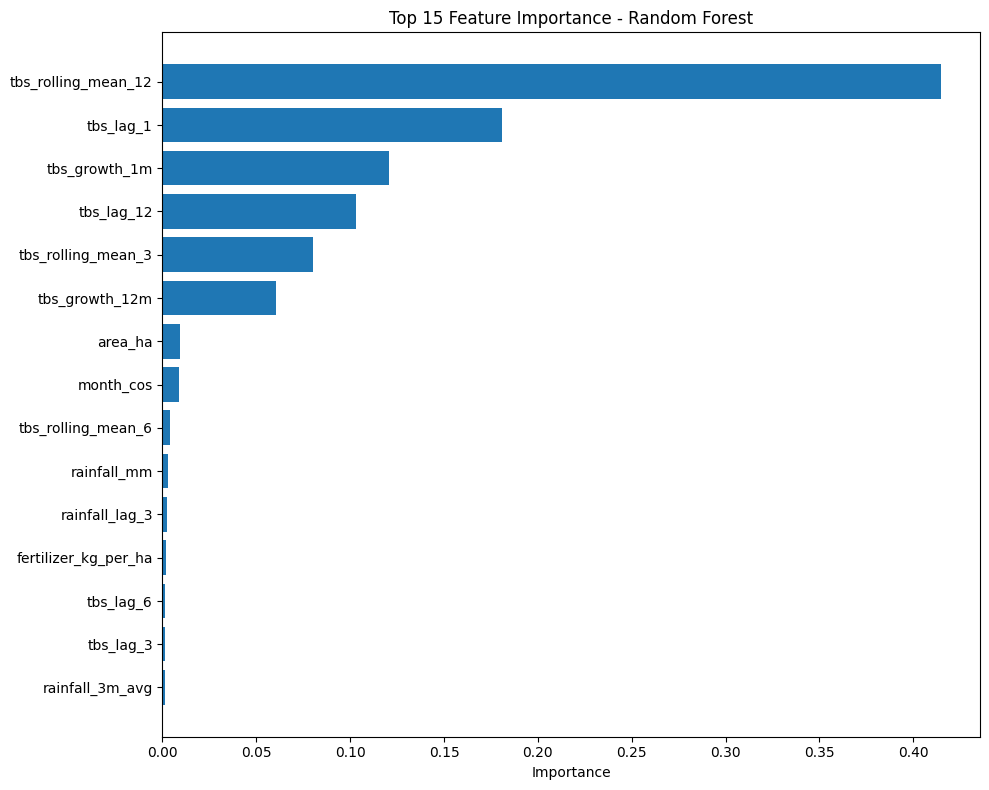

In [ ]:
plt.figure(figsize=(10, 8))

top_features = feature_importance.head(15)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

# Combine All Model Results

In [ ]:
all_results = pd.concat(
    [
        naive_results,
        seasonal_results,
        hw_results,
        sarima_results,
        rf_results[
            [
                "date",
                "estate_id",
                "actual",
                "forecast",
                "model"
            ]
        ]
    ],
    ignore_index=True
)

In [ ]:
all_results.head()

,date,estate_id,actual,forecast,model
0,2025-01-01,EST001,8385.6,9199.8,Naive
1,2025-02-01,EST001,9219.1,9199.8,Naive
2,2025-03-01,EST001,8661.8,9199.8,Naive
3,2025-04-01,EST001,10508.3,9199.8,Naive
4,2025-05-01,EST001,10733.9,9199.8,Naive


# Model Comparison

In [ ]:
model_comparison = []

for model_name, group in all_results.groupby("model"):

    mae, rmse, mape = calculate_metrics(
        group["actual"],
        group["forecast"]
    )

    model_comparison.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

In [ ]:
model_comparison = pd.DataFrame(
    model_comparison
)

In [ ]:
model_comparison.sort_values(
    "MAPE"
)

,model,MAE,RMSE,MAPE
2,Random Forest,160.650625,255.661940,1.648470
0,Holt-Winters,788.138302,1001.911148,8.430236
4,Seasonal Naive,824.109583,1036.151644,8.651075
1,Naive,975.953333,1228.357482,9.902923
3,SARIMA,13765.835901,41841.305267,147.536486


# Visual Comparison

In [ ]:
selected_estate = test_df[
    "estate_id"
].iloc[0]

comparison_estate = all_results[
    all_results["estate_id"] == selected_estate
]

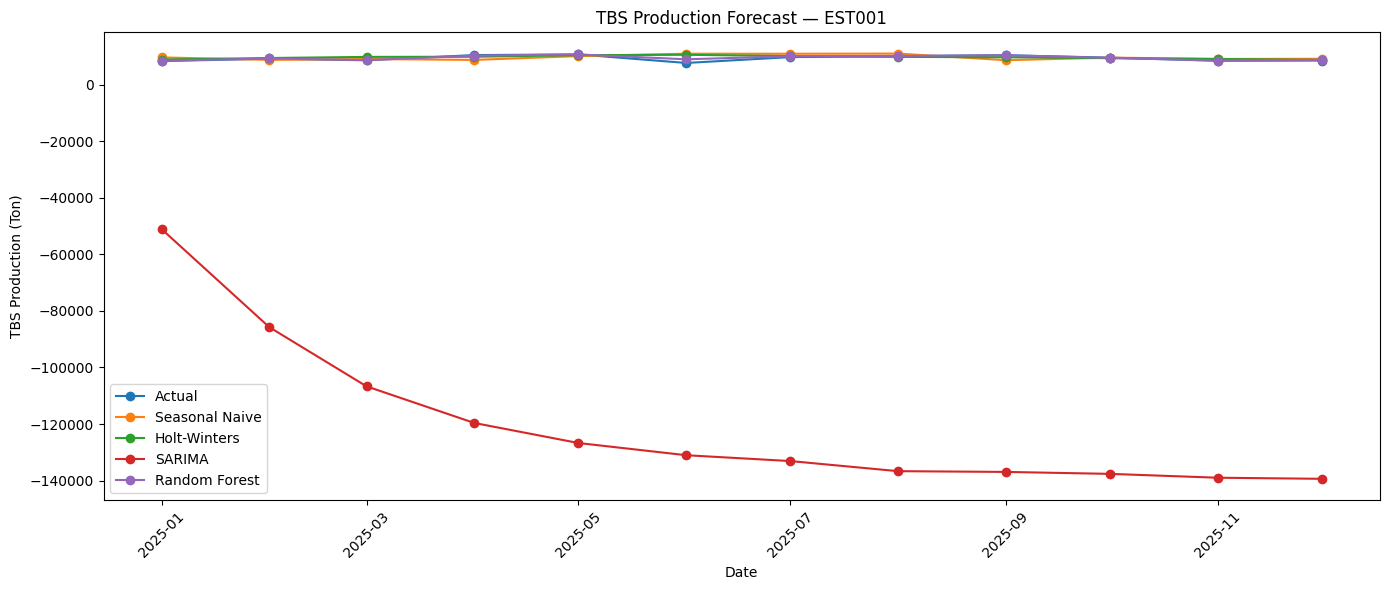

In [ ]:
plt.figure(figsize=(14, 6))

actual_data = (
    comparison_estate[
        comparison_estate["model"] == "Naive"
    ]
)

plt.plot(
    actual_data["date"],
    actual_data["actual"],
    marker="o",
    label="Actual"
)

for model_name in [
    "Seasonal Naive",
    "Holt-Winters",
    "SARIMA",
    "Random Forest"
]:

    model_data = comparison_estate[
        comparison_estate["model"] == model_name
    ]

    plt.plot(
        model_data["date"],
        model_data["forecast"],
        marker="o",
        label=model_name
    )

plt.title(
    f"TBS Production Forecast — {selected_estate}"
)

plt.xlabel("Date")
plt.ylabel("TBS Production (Ton)")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Forecast Error

In [ ]:
all_results["error"] = (
    all_results["actual"] -
    all_results["forecast"]
)

In [ ]:
all_results["absolute_error"] = (
    all_results["error"].abs()
)

## Save Results

In [ ]:
all_results.to_csv(
    PROCESSED_DIR / "forecast_results.csv",
    index=False
)

In [ ]:
model_comparison.to_csv(
    PROCESSED_DIR / "model_comparison.csv",
    index=False
)

## Final Check

In [ ]:
print("Forecast results:", all_results.shape)
print("Model comparison:")
display(model_comparison)

Forecast results: (600, 7)
Model comparison:


,model,MAE,RMSE,MAPE
0,Holt-Winters,788.138302,1001.911148,8.430236
1,Naive,975.953333,1228.357482,9.902923
2,Random Forest,160.650625,255.661940,1.648470
3,SARIMA,13765.835901,41841.305267,147.536486
4,Seasonal Naive,824.109583,1036.151644,8.651075
